<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Simulate_TMS_fMRI_ANN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulate TMS-fMRI Sessions with V2 Parameters
## Control: REST Initialization for Both Conditions (Amplitude-Only Comparison)

**Version 2 Key Changes:**
- **BURN_IN:** 30 (was 10)
- **NOISE_SIGMA:** 0.28 (was 0.45)
- **STIM_AMP:** 10.0 (was 100.0)
- **RHO_MM:** 60.0 (was 50.0)
- **Control Design:** Both REST and STIM(amp=0) use REST empirical initialization
  - This isolates the amplitude effect from initialization effects
  - True amplitude-only comparison: same brain state, different amplitude

**Validation:** Includes full FC analysis + comparative plots of STIM_AMP vs STIM_AMP=0

<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Simulate_TMS_fMRI_ANN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/grabuffo/BrainStim_ANN_fMRI_HCP/blob/main/notebooks/Simulate_TMS_fMRI_ANN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulate TMS-fMRI Sessions with Subject-Specific, Stimulus-Agnostic ANN Models

**Objective:** Use subject-specific models trained on TMS data (without explicit stimulus encoding) to simulate both resting-state and stimulation sessions with empirical TMS timing and target location information.

**Key Innovation:** Unlike stimulus-aware models, these models capture intrinsic brain dynamics learned from recordings during stimulation. When we apply realistic TMS timing and spatial location during simulation, we test whether learned dynamics naturally respond to stimulation constraints.

**Workflow:**
1. Load subject-specific stimulus-agnostic MLP models trained on concatenated TMS sessions
2. Load empirical dataset with rest and stim sessions, including TMS target regions and timing
3. For each subject, generate synthetic sessions:
   - Rest: Simulate resting-state activity without stimulation
   - Stim: Simulate brain response to empirical TMS timing and target location using spatial Gaussian kernel
4. Save simulated dataset to preprocessed_subjects_tms_fmri
5. Validate simulations match empirical functional connectivity

## Step 1: Setup and Configuration

In [16]:
# --- Setup ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, sys, pickle, json, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Clone repo + add to path
repo_dir = "/content/BrainStim_ANN_fMRI_HCP"
if not os.path.exists(repo_dir):
    !git clone https://github.com/grabuffo/BrainStim_ANN_fMRI_HCP.git
else:
    print("Repo already exists ✅")

sys.path.append(repo_dir)
from src.preprocessing_tms_fmri import preprocess_run
from src.NPI import build_model, device

print(f"PyTorch device: {device}")

Mounted at /content/drive
Repo already exists ✅
PyTorch device: cpu


In [17]:
# --- Configuration Parameters ---
ROI_num = 450
using_steps = 3
tr_rest = 2.0
tr_stim = 2.4
remove_initial_trs = 12  # Matching new model training (not 30)
low_hz, high_hz = 0.008, 0.08

# Simulation parameters (NEW VALUES)
BURN_IN = 30
NOISE_SIGMA = 0.28
STIM_AMP = 10.0
STIM_DURATION_S = tr_stim
RHO_MM = 60.0  # Gaussian spread (mm) for spatial TMS effect

rng = np.random.default_rng(42)

# Paths
base_dir = "/content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data"
data_dir = os.path.join(base_dir, "TMS_fMRI")
preproc_dir = os.path.join(base_dir, "preprocessed_subjects_tms_fmri")
dataset_pkl = os.path.join(data_dir, "dataset_tian50_schaefer400_allruns.pkl")

# Load models from NEW training workflow
weights_dir = os.path.join(preproc_dir, "trained_models_MLP")  # New stimulus-agnostic models

# Output directory for simulated dataset
out_dir = os.path.join(preproc_dir, "simulated_tms_fmri_stim_info_v2")
os.makedirs(out_dir, exist_ok=True)

out_pkl = os.path.join(out_dir, "dataset_simulated_with_stim_info.pkl")
results_json = os.path.join(out_dir, "simulation_summary.json")

print(f"Base dir: {base_dir}")
print(f"Weights dir: {weights_dir}")
print(f"Output dir: {out_dir}")
print(f"\nConfiguration:")
print(f"  ROI_num: {ROI_num}, using_steps: {using_steps}")
print(f"  TR_rest: {tr_rest}s, TR_stim: {tr_stim}s")
print(f"  remove_initial_trs: {remove_initial_trs}")
print(f"  BURN_IN: {BURN_IN}, NOISE_SIGMA: {NOISE_SIGMA}, STIM_AMP: {STIM_AMP}, RHO_MM: {RHO_MM}mm")

Base dir: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data
Weights dir: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP
Output dir: /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2

Configuration:
  ROI_num: 450, using_steps: 3
  TR_rest: 2.0s, TR_stim: 2.4s
  remove_initial_trs: 12
  BURN_IN: 30, NOISE_SIGMA: 0.28, STIM_AMP: 10.0, RHO_MM: 60.0mm


## Step 2: Load Distance Matrix and Spatial Gaussian Kernel

In [18]:
# --- Load distance matrix for spatial Gaussian kernel ---
try:
    dist_path = os.path.join(data_dir, "atlases", "distance_matrix_450x450_Tian50_Schaefer400.npy")
    D = np.load(dist_path)
    W = np.exp(-(D ** 2) / (2.0 * (RHO_MM ** 2))).astype(np.float32)
    W /= (W[np.arange(ROI_num), np.arange(ROI_num)][:, None] + 1e-8)  # Normalize so target = 1
    print(f"✓ Loaded distance matrix: W shape {W.shape}, range [{W.min():.4f}, {W.max():.4f}]")
    print(f"  Gaussian spread: RHO_MM = {RHO_MM} mm")
    print(f"  Diagonal values (self-weights): {W.diagonal()[:5]}...")
except FileNotFoundError as e:
    print(f"⚠ Distance matrix not found: {e}")
    print(f"  Will use direct stimulation only (no spatial spread)")
    W = None

✓ Loaded distance matrix: W shape (450, 450), range [0.0176, 1.0000]
  Gaussian spread: RHO_MM = 60.0 mm
  Diagonal values (self-weights): [1. 1. 1. 1. 1.]...


## Step 3: Define Model Architecture and Load Trained Models

In [19]:
# --- Model Architecture: Stimulus-Agnostic MLP ---
# Using NPI helper function instead of defining class manually
# Model architecture:
#   Input: Brain state only (using_steps * ROI_num dimensions = 3 * 450 = 1350)
#   Hidden layers: 256 → 128 hidden units with ReLU activations
#   Output: Next predicted ROI activation (450 dims)
# Key difference from old models: NO stimulus encoding. Just intrinsic dynamics.

print("✓ Will instantiate models using src.NPI.build_model()")

✓ Will instantiate models using src.NPI.build_model()


In [20]:
# --- Load subject-specific trained models ---
print("Loading subject-specific stimulus-agnostic models...\n")

trained_models = {}
model_pattern = '_MLP.pt'  # New models save as sub-ID_MLP.pt

# List available model files
if os.path.exists(weights_dir):
    model_files = [f for f in os.listdir(weights_dir) if f.endswith(model_pattern)]
    print(f"Found {len(model_files)} model files in {weights_dir}")
else:
    print(f"⚠ Weights directory not found: {weights_dir}")
    model_files = []

for model_file in sorted(model_files):
    sub_id = model_file.replace(model_pattern, '')
    model_path = os.path.join(weights_dir, model_file)

    try:
        # Load the checkpoint
        torch.serialization.add_safe_globals([torch.nn.modules.linear.Linear, torch.nn.modules.activation.ReLU])
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)

        # Handle both cases: saved as state_dict or as full model
        if isinstance(checkpoint, dict):
            # Case 1: Saved as state_dict
            model = build_model("MLP", ROI_num=ROI_num, using_steps=using_steps).to(device)
            model.load_state_dict(checkpoint)
        else:
            # Case 2: Saved as full model object
            model = checkpoint.to(device) if hasattr(checkpoint, 'to') else checkpoint

        model.eval()
        trained_models[sub_id] = model
        print(f"✓ {sub_id}")
    except Exception as e:
        print(f"✗ {sub_id} - skipping ({str(e)[:50]}...)")

print(f"\n✅ Loaded {len(trained_models)} models ready for simulation")

Loading subject-specific stimulus-agnostic models...

Found 35 model files in /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/trained_models_MLP
✓ sub-NTHC1015
✓ sub-NTHC1019
✓ sub-NTHC1022
✓ sub-NTHC1024
✓ sub-NTHC1027
✓ sub-NTHC1028
✓ sub-NTHC1029
✓ sub-NTHC1032
✓ sub-NTHC1035
✓ sub-NTHC1036
✓ sub-NTHC1037
✓ sub-NTHC1038
✓ sub-NTHC1039
✓ sub-NTHC1040
✓ sub-NTHC1043
✓ sub-NTHC1047
✓ sub-NTHC1049
✓ sub-NTHC1050
✓ sub-NTHC1052
✓ sub-NTHC1053
✓ sub-NTHC1055
✓ sub-NTHC1056
✓ sub-NTHC1061
✓ sub-NTHC1062
✓ sub-NTHC1064
✓ sub-NTHC1066
✓ sub-NTHC1068
✓ sub-NTHC1073
✓ sub-NTHC1098
✓ sub-NTHC1099
✓ sub-NTHC1101
✓ sub-NTHC1102
✓ sub-NTHC1105
✓ sub-NTHC1107
✓ sub-NTHC1108

✅ Loaded 35 models ready for simulation


## Step 4: Load Empirical Dataset and Verify Subject Matching

In [21]:
# --- Load empirical dataset ---
print(f"Loading empirical dataset from {dataset_pkl}...")
with open(dataset_pkl, "rb") as f:
    dataset_emp = pickle.load(f)

print(f"✓ Loaded {len(dataset_emp)} subjects")

# Verify dataset structure
sample_sub = list(dataset_emp.keys())[0]
print(f"\nSample subject: {sample_sub}")
print(f"  Available conditions: {list(dataset_emp[sample_sub].keys())}")
if 'task-rest' in dataset_emp[sample_sub]:
    sample_rest = dataset_emp[sample_sub]['task-rest']
    print(f"  Rest runs: {list(sample_rest.keys())[:3]}...")
    first_rest_run = list(sample_rest.values())[0]
    print(f"  Rest data keys: {list(first_rest_run.keys())}")
    if 'time series' in first_rest_run:
        print(f"  Rest TS shape: {first_rest_run['time series'].shape}")

if 'task-stim' in dataset_emp[sample_sub]:
    sample_stim = dataset_emp[sample_sub]['task-stim']
    print(f"  Stim runs: {list(sample_stim.keys())[:3]}...")
    first_stim_run = list(sample_stim.values())[0]
    print(f"  Stim data keys: {list(first_stim_run.keys())}")
    if 'target' in first_stim_run:
        print(f"  Stim target: {first_stim_run['target']}")
    if 'stim time' in first_stim_run:
        print(f"  Stim time type: {type(first_stim_run['stim time'])}")

# Match models to empirical data
subjects_with_models_and_data = []
for sub_id in trained_models.keys():
    if sub_id in dataset_emp:
        subjects_with_models_and_data.append(sub_id)

print(f"\n{'='*70}")
print(f"Subjects with both trained models AND empirical data: {len(subjects_with_models_and_data)}")
print(f"  {subjects_with_models_and_data[:5]}..." if len(subjects_with_models_and_data) > 5 else f"  {subjects_with_models_and_data}")
print(f"{'='*70}")

Loading empirical dataset from /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/TMS_fMRI/dataset_tian50_schaefer400_allruns.pkl...


/tmp/ipykernel_389/1310336082.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataset_emp = pickle.load(f)


✓ Loaded 46 subjects

Sample subject: sub-NTHC1001
  Available conditions: ['task-rest', 'task-stim']
  Rest runs: [0]...
  Rest data keys: ['time series', 'metadata']
  Rest TS shape: (240, 450)
  Stim runs: [0]...
  Stim data keys: ['time series', 'metadata', 'target', 'stim time']
  Stim target: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

## Step 5: Simulation Helper Functions

In [22]:
print("\n" + "="*70)
print("METRIC: Per-Target FC Correlation Analysis (CORTICAL ONLY)")
print("="*70)
print("Using Schaefer 400 cortical ROIs (indices 50-449)...")
print("Computing: Rest FC, Stim FC, Delta FC (stim - rest)\n")

# Extract cortical ROIs only (Schaefer: indices 50-449)
cortical_roi_indices = np.arange(50, 450)
n_cortical = len(cortical_roi_indices)
print(f"Cortical ROIs: {n_cortical} (indices {cortical_roi_indices[0]}-{cortical_roi_indices[-1]})\n")

# Organize FC matrices by target (cortical only)
fc_by_target_emp = {}
fc_by_target_sim = {}

for sub_id in sorted(dataset_sim.keys()):
    if sub_id not in dataset_emp:
        continue

    # Collect rest FC
    ts_rest_emp_list = []
    ts_rest_sim_list = []

    if "task-rest" in dataset_emp[sub_id]:
        for run_idx, run in dataset_emp[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_drop = ts[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_emp_list.append(ts_cortical)

    if "task-rest" in dataset_sim[sub_id]:
        for run_idx, run in dataset_sim[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_proc = preprocess_run(ts, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_sim_list.append(ts_cortical)

    if ts_rest_emp_list and ts_rest_sim_list:
        fc_rest_emp = compute_fc_matrix(np.vstack(ts_rest_emp_list))
        fc_rest_sim = compute_fc_matrix(np.vstack(ts_rest_sim_list))

        # Collect stim FC per target
        if "task-stim" in dataset_sim[sub_id] and "task-stim" in dataset_emp[sub_id]:
            emp_stim = dataset_emp[sub_id]["task-stim"]
            sim_stim = dataset_sim[sub_id]["task-stim"]

            for run_idx in sim_stim.keys():
                if run_idx not in emp_stim:
                    continue

                ts_emp = emp_stim[run_idx].get("time series")
                ts_sim = sim_stim[run_idx].get("time series")
                target_vec = emp_stim[run_idx].get("target")

                if ts_emp is None or ts_sim is None:
                    continue

                target_idx = safe_target_idx(target_vec)
                if target_idx is None:
                    continue

                ts_emp_drop = ts_emp[remove_initial_trs:, :]
                ts_emp_proc = preprocess_run(ts_emp_drop, tr=tr_stim, n_drop=0,
                                            low=low_hz, high=high_hz, order=2, zscore=True)
                ts_sim_proc = preprocess_run(ts_sim, tr=tr_stim, n_drop=0,
                                            low=low_hz, high=high_hz, order=2, zscore=True)

                if ts_emp_proc.shape[0] <= using_steps or ts_sim_proc.shape[0] <= using_steps:
                    continue

                ts_emp_cortical = ts_emp_proc[:, cortical_roi_indices]
                ts_sim_cortical = ts_sim_proc[:, cortical_roi_indices]

                fc_stim_emp = compute_fc_matrix(ts_emp_cortical)
                fc_stim_sim = compute_fc_matrix(ts_sim_cortical)

                if target_idx not in fc_by_target_emp:
                    fc_by_target_emp[target_idx] = {"rest": [], "stim": []}
                    fc_by_target_sim[target_idx] = {"rest": [], "stim": []}

                fc_by_target_emp[target_idx]["rest"].append(fc_rest_emp)
                fc_by_target_emp[target_idx]["stim"].append(fc_stim_emp)
                fc_by_target_sim[target_idx]["rest"].append(fc_rest_sim)
                fc_by_target_sim[target_idx]["stim"].append(fc_stim_sim)

print(f"Processed {len(fc_by_target_emp)} unique stimulation targets\n")

# Compute correlations per target
target_results = {}

for target_idx in sorted(fc_by_target_emp.keys()):
    emp_rest_list = fc_by_target_emp[target_idx]["rest"]
    emp_stim_list = fc_by_target_emp[target_idx]["stim"]
    sim_rest_list = fc_by_target_sim[target_idx]["rest"]
    sim_stim_list = fc_by_target_sim[target_idx]["stim"]

    if len(emp_rest_list) == 0 or len(emp_stim_list) == 0:
        continue

    # Average FC matrices
    mean_fc_rest_emp = np.mean(emp_rest_list, axis=0)
    mean_fc_stim_emp = np.mean(emp_stim_list, axis=0)
    mean_fc_rest_sim = np.mean(sim_rest_list, axis=0)
    mean_fc_stim_sim = np.mean(sim_stim_list, axis=0)

    # Compute delta FC
    mean_fc_delta_emp = mean_fc_stim_emp - mean_fc_rest_emp
    mean_fc_delta_sim = mean_fc_stim_sim - mean_fc_rest_sim

    # Extract upper triangles
    rest_emp_vec = extract_upper_triangle(mean_fc_rest_emp)
    rest_sim_vec = extract_upper_triangle(mean_fc_rest_sim)
    stim_emp_vec = extract_upper_triangle(mean_fc_stim_emp)
    stim_sim_vec = extract_upper_triangle(mean_fc_stim_sim)
    delta_emp_vec = extract_upper_triangle(mean_fc_delta_emp)
    delta_sim_vec = extract_upper_triangle(mean_fc_delta_sim)

    # Compute correlations
    r_rest = np.corrcoef(rest_emp_vec, rest_sim_vec)[0, 1]
    r_stim = np.corrcoef(stim_emp_vec, stim_sim_vec)[0, 1]
    r_delta = np.corrcoef(delta_emp_vec, delta_sim_vec)[0, 1]

    target_results[target_idx] = {
        "r_rest": float(r_rest) if not np.isnan(r_rest) else 0.0,
        "r_stim": float(r_stim) if not np.isnan(r_stim) else 0.0,
        "r_delta": float(r_delta) if not np.isnan(r_delta) else 0.0,
        "n_subjects": len(emp_rest_list),
    }

print(f"Per-Target FC Correlations (CORTICAL ONLY):")
print(f"{'Target':<8} {'r_rest':<12} {'r_stim':<12} {'r_delta':<12} {'N_subj':<8}")
print("-" * 60)

for target_idx in sorted(target_results.keys()):
    res = target_results[target_idx]
    print(f"Target {target_idx:<2} {res['r_rest']:>10.4f}   {res['r_stim']:>10.4f}   {res['r_delta']:>10.4f}   {res['n_subjects']:>6}")

# Summary statistics
all_r_rest = [v["r_rest"] for v in target_results.values()]
all_r_stim = [v["r_stim"] for v in target_results.values()]
all_r_delta = [v["r_delta"] for v in target_results.values()]

print("\n" + "="*70)
print("Overall Summary (NORMAL SIMULATION):")
print(f"  Rest FC:  μ={np.mean(all_r_rest):.4f}, σ={np.std(all_r_rest):.4f}")
print(f"  Stim FC:  μ={np.mean(all_r_stim):.4f}, σ={np.std(all_r_stim):.4f}")
print(f"  Delta FC: μ={np.mean(all_r_delta):.4f}, σ={np.std(all_r_delta):.4f}")
print("="*70)


METRIC: Per-Target FC Correlation Analysis (CORTICAL ONLY)
Using Schaefer 400 cortical ROIs (indices 50-449)...
Computing: Rest FC, Stim FC, Delta FC (stim - rest)

Cortical ROIs: 400 (indices 50-449)

Processed 11 unique stimulation targets

Per-Target FC Correlations (CORTICAL ONLY):
Target   r_rest       r_stim       r_delta      N_subj  
------------------------------------------------------------
Target 155     0.9204       0.7039       0.2082       37
Target 220     0.9095       0.6458       0.2726       27
Target 231     0.9204       0.7167       0.2926       37
Target 305     0.9204       0.7673       0.2877       37
Target 342     0.9204       0.7763       0.2505       37
Target 359     0.9204       0.7304       0.1875       37
Target 366     0.9201       0.7459       0.2506       34
Target 386     0.9093       0.7154       0.2662       27
Target 392     0.9193       0.7163       0.2143       34
Target 401     0.9204       0.7712       0.2565       37
Target 403     0.9199   

In [23]:
# --- Helper Functions for Data Parsing ---

def safe_target_idx(target_vec):
    """Extract target region index from one-hot vector."""
    if target_vec is None:
        return None
    v = np.asarray(target_vec).astype(int).ravel()
    if v.size == 0 or v.sum() != 1:
        return None
    return int(np.argmax(v))

def get_onset_column(df):
    """Find onset column in dataframe."""
    if df is None or len(df) == 0:
        return None
    for col in ["onset", "Onset", "stim_onset", "onset_s", "onset_sec", "time", "t", "seconds"]:
        if col in df.columns:
            return col
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            return col
    return None

def map_onsets_to_steps(onsets_s, tr_model=tr_stim, mode="round"):
    """Map stimulus onsets (seconds) to model steps.

    After removing initial TRs, stimulus times are relative to start of cleaned data.
    This function converts seconds to simulation step indices.
    """
    onsets_s = np.asarray(onsets_s, dtype=float)
    x = onsets_s / float(tr_model)
    if mode == "round":
        steps = np.rint(x).astype(int)
    elif mode == "floor":
        steps = np.floor(x).astype(int)
    else:
        steps = np.ceil(x).astype(int)
    steps = steps[steps >= 0]
    return np.unique(steps)

print("✓ Helper functions defined")

✓ Helper functions defined


In [24]:
# --- Neural Network Inference ---

@torch.no_grad()
def predict_next(model, window_SxN):
    """Predict next state from rolling window of brain state.

    For stimulus-agnostic models:
    - Input: flattened brain state from using_steps (1350 dims for 3 steps × 450 ROIs)
    - Output: next predicted ROI activation (450 dims)
    - Noise is added to output for stochasticity

    Args:
        model: ANN_MLP model instance
        window_SxN: (using_steps, ROI_num) array of recent brain states

    Returns:
        (ROI_num,) predicted next state with noise
    """
    # Flatten brain state
    brain_state = window_SxN.reshape(-1).astype(np.float32)

    # Add input noise
    noise = NOISE_SIGMA * rng.normal(0.0, 1.0, size=brain_state.shape).astype(np.float32)
    brain_state = brain_state + noise

    # Forward pass
    x = torch.tensor(brain_state[None, :], dtype=torch.float32, device=device)
    y = model(x)

    return y.detach().cpu().numpy().squeeze(0)

def simulate_run(model, init_window_SxN, n_steps, stim_steps=None, target_idx=None, W=None, stim_amplitude=None):
    """Simulate brain activity time series with optional TMS stimulation.

    The model learns intrinsic dynamics during normal brain function.
    When we apply stimulation, we perturb the state at the target region using:
    - Spatial Gaussian kernel (W) to spread stimulation across regions
    - Empirical stimulus timing (stim_steps) to apply perturbations at correct times

    Args:
        model: Trained ANN_MLP
        init_window_SxN: (using_steps, ROI_num) initial brain state window
        n_steps: Number of simulation steps
        stim_steps: Set of step indices when stimulation occurs
        target_idx: Target ROI for stimulation (0-449)
        W: (ROI_num, ROI_num) spatial Gaussian kernel for TMS spread
        stim_amplitude: Stimulation amplitude. If None, uses global STIM_AMP. Set to 0.0 for control (no perturbation).

    Returns:
        (n_steps, ROI_num) simulated time series
    """
    init_window_SxN = np.asarray(init_window_SxN, dtype=np.float32)
    assert init_window_SxN.shape == (using_steps, ROI_num)

    # Use provided amplitude or default to global STIM_AMP
    if stim_amplitude is None:
        stim_amplitude = STIM_AMP

    # Prepare stimulation parameters
    if stim_steps is not None:
        stim_steps = set(int(s) for s in stim_steps)
    else:
        stim_steps = set()

    do_stim = (target_idx is not None) and (len(stim_steps) > 0)

    w = init_window_SxN.copy()

    # Burn-in phase: let model settle to attractor without stimulation
    for _ in range(BURN_IN):
        y = predict_next(model, w)
        w = np.vstack([w[1:], y[None, :]])

    # Simulate with optional spatial TMS
    out = np.zeros((n_steps, ROI_num), dtype=np.float32)
    for t in range(n_steps):
        # Apply stimulation if this is a stim step
        if do_stim and (t in stim_steps):
            if W is not None:
                # Apply spatial Gaussian spread of stimulation
                w[-1, :] += stim_amplitude * W[target_idx, :]
            else:
                # No spatial kernel - apply to target region only
                w[-1, target_idx] += stim_amplitude

        # Get model prediction
        y = predict_next(model, w)
        out[t] = y

        # Update rolling window
        w = np.vstack([w[1:], y[None, :]])

    return out

print("✓ Simulation functions defined")

✓ Simulation functions defined


## Step 6: Functional Connectivity Computation

In [25]:
# --- Functional Connectivity Functions ---

def compute_fc_matrix(time_series):
    """Compute functional connectivity (Pearson correlation) matrix.

    Args:
        time_series: (T, ROI_num) time series array

    Returns:
        (ROI_num, ROI_num) correlation matrix
    """
    ts_std = (time_series - time_series.mean(axis=0)) / (time_series.std(axis=0) + 1e-8)
    fc = np.corrcoef(ts_std.T)
    return fc

def extract_upper_triangle(fc_matrix):
    """Extract upper triangle of FC matrix (excluding diagonal) as vector.

    For comparison, this removes redundant lower triangle and diagonal.
    """
    N = fc_matrix.shape[0]
    indices = np.triu_indices(N, k=1)
    return fc_matrix[indices]

print("✓ FC computation functions defined")

✓ FC computation functions defined


## Step 7: Generate Simulated Dataset Using Empirical TMS Parameters

In [26]:
# --- Generate synthetic dataset ---
print("="*70)
print("GENERATING SIMULATED DATASET")
print("="*70)
print("\nFor each subject with trained model:")
print("  1. Simulate REST sessions (no stimulation)")
print("  2. Simulate STIM sessions (with empirical TMS timing & target)")
print()

dataset_sim = {}
n_sim_rest = 0
n_sim_stim = 0
sim_errors = []

for sub_id in sorted(subjects_with_models_and_data):
    model = trained_models[sub_id]
    sub_data_emp = dataset_emp[sub_id]

    dataset_sim[sub_id] = {"task-rest": {}, "task-stim": {}}

    # ---- SIMULATE REST ----
    if "task-rest" in sub_data_emp:
        rest_count = 0
        for run_idx, run_emp in sub_data_emp["task-rest"].items():
            ts_emp = run_emp.get("time series", None)

            # Validate data
            if ts_emp is None or not isinstance(ts_emp, np.ndarray) or ts_emp.shape[1] != ROI_num:
                continue

            try:
                # Preprocess empirical rest (drop TRs, bandpass, z-score)
                ts_drop = ts_emp[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

                if ts_proc.shape[0] <= using_steps:
                    continue

                # Use first using_steps timesteps as initial window, no stimulation
                init_window = ts_proc[:using_steps].copy()
                n_steps = ts_proc.shape[0]

                # Simulate rest
                sim_ts = simulate_run(model, init_window, n_steps,
                                    stim_steps=None, target_idx=None, W=None)

                dataset_sim[sub_id]["task-rest"][int(run_idx)] = {
                    "time series": sim_ts,
                    "metadata": {"simulated": True, "tr": float(tr_rest), "n_vols": n_steps}
                }
                rest_count += 1
                n_sim_rest += 1
            except Exception as e:
                sim_errors.append(f"{sub_id} rest run {run_idx}: {str(e)[:60]}")

        if rest_count > 0:
            print(f"  {sub_id}: Simulated {rest_count} rest sessions")

    # ---- SIMULATE STIM ----
    if "task-stim" in sub_data_emp:
        stim_count = 0
        for run_idx, run_emp in sub_data_emp["task-stim"].items():
            ts_emp = run_emp.get("time series", None)
            target_vec = run_emp.get("target", None)
            stim_time_df = run_emp.get("stim time", None)

            # Validate data
            if ts_emp is None or not isinstance(ts_emp, np.ndarray) or ts_emp.shape[1] != ROI_num:
                continue

            # Extract target region
            target_idx = safe_target_idx(target_vec)
            if target_idx is None:
                continue

            try:
                # Preprocess empirical stim (drop TRs, bandpass, z-score)
                ts_drop = ts_emp[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

                if ts_proc.shape[0] <= using_steps:
                    continue

                # Extract stimulus timing
                stim_steps_model = []
                if stim_time_df is not None and len(stim_time_df) > 0:
                    onset_col = get_onset_column(stim_time_df)
                    if onset_col is not None:
                        onsets_s = stim_time_df[onset_col].values
                        # Subtract initial TRs that were dropped (in seconds)
                        onsets_s = onsets_s[onsets_s >= remove_initial_trs * tr_stim]
                        onsets_s = onsets_s - remove_initial_trs * tr_stim
                        stim_steps_model = map_onsets_to_steps(onsets_s, tr_model=tr_stim)

                if len(stim_steps_model) == 0:
                    # No valid stimulation times
                    continue

                # Use first using_steps timesteps as initial window
                init_window = ts_proc[:using_steps].copy()
                n_steps = ts_proc.shape[0]

                # Simulate stim with empirical target and timing
                sim_ts = simulate_run(model, init_window, n_steps,
                                    stim_steps=stim_steps_model, target_idx=target_idx, W=W)

                dataset_sim[sub_id]["task-stim"][int(run_idx)] = {
                    "time series": sim_ts,
                    "target": target_vec,
                    "stim time": stim_time_df,
                    "metadata": {
                        "simulated": True,
                        "tr": float(tr_stim),
                        "target_idx": int(target_idx),
                        "n_stim_pulses": len(stim_steps_model),
                        "n_vols": n_steps
                    }
                }
                stim_count += 1
                n_sim_stim += 1
            except Exception as e:
                sim_errors.append(f"{sub_id} stim run {run_idx}: {str(e)[:60]}")

        if stim_count > 0:
            print(f"  {sub_id}: Simulated {stim_count} stim sessions")

print("\n" + "="*70)
print(f"✓ Generated {n_sim_rest} rest sessions and {n_sim_stim} stim sessions")
print(f"✓ Simulated {len(dataset_sim)} subjects total")

if sim_errors:
    print(f"\n⚠ Encountered {len(sim_errors)} errors during simulation:")
    for err in sim_errors[:3]:
        print(f"  {err}")
    if len(sim_errors) > 3:
        print(f"  ... and {len(sim_errors)-3} more")

GENERATING SIMULATED DATASET

For each subject with trained model:
  1. Simulate REST sessions (no stimulation)
  2. Simulate STIM sessions (with empirical TMS timing & target)

  sub-NTHC1015: Simulated 2 rest sessions
  sub-NTHC1015: Simulated 18 stim sessions
  sub-NTHC1019: Simulated 2 rest sessions
  sub-NTHC1019: Simulated 9 stim sessions
  sub-NTHC1022: Simulated 1 rest sessions
  sub-NTHC1022: Simulated 9 stim sessions
  sub-NTHC1024: Simulated 1 rest sessions
  sub-NTHC1024: Simulated 9 stim sessions
  sub-NTHC1027: Simulated 1 rest sessions
  sub-NTHC1027: Simulated 9 stim sessions
  sub-NTHC1028: Simulated 1 rest sessions
  sub-NTHC1028: Simulated 9 stim sessions
  sub-NTHC1029: Simulated 1 rest sessions
  sub-NTHC1029: Simulated 8 stim sessions
  sub-NTHC1032: Simulated 1 rest sessions
  sub-NTHC1032: Simulated 8 stim sessions
  sub-NTHC1035: Simulated 1 rest sessions
  sub-NTHC1035: Simulated 11 stim sessions
  sub-NTHC1036: Simulated 1 rest sessions
  sub-NTHC1036: Simula

## Step 7b: Generate Control Dataset - REST INIT for Both Conditions

**KEY INNOVATION**: Both REST and STIM (amplitude=0) use **REST empirical initialization**

This creates a **true amplitude-only comparison**:
- Same initial brain state (from REST)
- Different amplitude (100.0 vs 0.0)

This isolates the effect of stimulation amplitude from initialization effects.

In [27]:
# --- Generate control dataset with SAME REST INIT for both conditions ---
print("="*70)
print("GENERATING CONTROL DATASET (STIM_AMP = 0, REST INIT FOR BOTH)")
print("="*70)
print("\nFor each subject with trained model:")
print("  1. Simulate REST sessions (no stimulation, from REST init)")
print("  2. Simulate STIM sessions (STIM_AMP=0, FROM SAME REST INIT)")
print("     → Both use REST initialization for true amplitude-only comparison")
print()

STIM_AMP_CONTROL = 0.0  # Control: zero amplitude

dataset_sim_control = {}
n_sim_rest_control = 0
n_sim_stim_control = 0
sim_errors_control = []

for sub_id in sorted(subjects_with_models_and_data):
    model = trained_models[sub_id]
    sub_data_emp = dataset_emp[sub_id]

    dataset_sim_control[sub_id] = {"task-rest": {}, "task-stim": {}}

    # ----- FIRST PASS: COLLECT REST DATA FOR INITIALIZATION -----
    rest_init_windows = []  # Store (init_window, n_steps) pairs from rest sessions

    if "task-rest" in sub_data_emp:
        rest_count = 0
        for run_idx, run_emp in sub_data_emp["task-rest"].items():
            ts_emp = run_emp.get("time series", None)

            if ts_emp is None or not isinstance(ts_emp, np.ndarray) or ts_emp.shape[1] != ROI_num:
                continue

            try:
                ts_drop = ts_emp[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

                if ts_proc.shape[0] <= using_steps:
                    continue

                init_window = ts_proc[:using_steps].copy()
                n_steps = ts_proc.shape[0]
                rest_init_windows.append((init_window, n_steps))

                # Simulate REST (from REST init, no stimulation)
                sim_ts = simulate_run(model, init_window, n_steps,
                                    stim_steps=None, target_idx=None, W=None)

                dataset_sim_control[sub_id]["task-rest"][int(run_idx)] = {
                    "time series": sim_ts,
                    "metadata": {"simulated": True, "tr": float(tr_rest), "n_vols": n_steps}
                }
                rest_count += 1
                n_sim_rest_control += 1
            except Exception as e:
                sim_errors_control.append(f"{sub_id} rest run {run_idx}: {str(e)[:60]}")

        if rest_count > 0:
            print(f"  {sub_id}: Simulated {rest_count} rest sessions (from REST init)")

    # ----- SECOND PASS: SIMULATE STIM WITH CONTROL AMPLITUDE (STIM_AMP=0) & REST INIT -----
    if "task-stim" in sub_data_emp and rest_init_windows:
        stim_count = 0
        for run_idx, run_emp in sub_data_emp["task-stim"].items():
            ts_emp = run_emp.get("time series", None)
            target_vec = run_emp.get("target", None)
            stim_time_df = run_emp.get("stim time", None)

            if ts_emp is None or not isinstance(ts_emp, np.ndarray) or ts_emp.shape[1] != ROI_num:
                continue

            target_idx = safe_target_idx(target_vec)
            if target_idx is None:
                continue

            try:
                ts_drop = ts_emp[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

                if ts_proc.shape[0] <= using_steps:
                    continue

                # Extract stimulus timing
                stim_steps_model = []
                if stim_time_df is not None and len(stim_time_df) > 0:
                    onset_col = get_onset_column(stim_time_df)
                    if onset_col is not None:
                        onsets_s = stim_time_df[onset_col].values
                        onsets_s = onsets_s[onsets_s >= remove_initial_trs * tr_stim]
                        onsets_s = onsets_s - remove_initial_trs * tr_stim
                        stim_steps_model = map_onsets_to_steps(onsets_s, tr_model=tr_stim)

                if len(stim_steps_model) == 0:
                    continue

                # USE REST INITIALIZATION (NOT stim initialization)
                # Pick a matching-length rest window for initialization
                n_steps = ts_proc.shape[0]
                matching_rest = [w for w, ns in rest_init_windows if ns >= n_steps]

                if not matching_rest:
                    # Use the longest available rest window
                    matching_rest = [max(rest_init_windows, key=lambda x: x[1])[0]]

                init_window = matching_rest[0]  # Use first matching REST init

                # CONTROL: Apply STIM_AMP=0 stimulation from REST initialization
                sim_ts = simulate_run(model, init_window, n_steps,
                                    stim_steps=stim_steps_model, target_idx=target_idx, W=W,
                                    stim_amplitude=STIM_AMP_CONTROL)

                dataset_sim_control[sub_id]["task-stim"][int(run_idx)] = {
                    "time series": sim_ts,
                    "target": target_vec,
                    "stim time": stim_time_df,
                    "metadata": {
                        "simulated": True,
                        "tr": float(tr_stim),
                        "target_idx": int(target_idx),
                        "n_stim_pulses": len(stim_steps_model),
                        "n_vols": n_steps,
                        "stim_amp_applied": 0.0,  # Mark as control
                        "init_type": "REST",  # Mark that REST init was used
                    }
                }
                stim_count += 1
                n_sim_stim_control += 1
            except Exception as e:
                sim_errors_control.append(f"{sub_id} stim run {run_idx}: {str(e)[:60]}")

        if stim_count > 0:
            print(f"  {sub_id}: Simulated {stim_count} stim sessions (STIM_AMP=0, REST init)")

print("\n" + "="*70)
print(f"✓ [CONTROL] Generated {n_sim_rest_control} rest sessions and {n_sim_stim_control} stim sessions (STIM_AMP=0)")
print(f"✓ Both REST and STIM (control) use REST empirical initialization")
print(f"✓ Simulated {len(dataset_sim_control)} subjects total")

if sim_errors_control:
    print(f"\n⚠ Encountered {len(sim_errors_control)} errors during control simulation:")
    for err in sim_errors_control[:3]:
        print(f"  {err}")
    if len(sim_errors_control) > 3:
        print(f"  ... and {len(sim_errors_control)-3} more")


GENERATING CONTROL DATASET (STIM_AMP = 0, REST INIT FOR BOTH)

For each subject with trained model:
  1. Simulate REST sessions (no stimulation, from REST init)
  2. Simulate STIM sessions (STIM_AMP=0, FROM SAME REST INIT)
     → Both use REST initialization for true amplitude-only comparison

  sub-NTHC1015: Simulated 2 rest sessions (from REST init)
  sub-NTHC1015: Simulated 18 stim sessions (STIM_AMP=0, REST init)
  sub-NTHC1019: Simulated 2 rest sessions (from REST init)
  sub-NTHC1019: Simulated 9 stim sessions (STIM_AMP=0, REST init)
  sub-NTHC1022: Simulated 1 rest sessions (from REST init)
  sub-NTHC1022: Simulated 9 stim sessions (STIM_AMP=0, REST init)
  sub-NTHC1024: Simulated 1 rest sessions (from REST init)
  sub-NTHC1024: Simulated 9 stim sessions (STIM_AMP=0, REST init)
  sub-NTHC1027: Simulated 1 rest sessions (from REST init)
  sub-NTHC1027: Simulated 9 stim sessions (STIM_AMP=0, REST init)
  sub-NTHC1028: Simulated 1 rest sessions (from REST init)
  sub-NTHC1028: Simu

## Step 8: Save Simulated Datasets

In [28]:
# --- Save both datasets ---
print("\nSaving results to preprocessed_subjects_tms_fmri...")

# Save normal dataset
with open(out_pkl, "wb") as f:
    pickle.dump(dataset_sim, f)
print(f"✓ Saved normal simulated dataset to {out_pkl}")

# Save control dataset
out_pkl_control = os.path.join(out_dir, "dataset_simulated_control_REST_INIT_only.pkl")
with open(out_pkl_control, "wb") as f:
    pickle.dump(dataset_sim_control, f)
print(f"✓ Saved control simulated dataset to {out_pkl_control}")

# Create summaries
summary = {
    "metadata": {
        "date": pd.Timestamp.now().isoformat(),
        "model_type": "stimulus-agnostic MLP",
        "n_subjects_simulated": len(dataset_sim),
        "n_rest_sessions": n_sim_rest,
        "n_stim_sessions": n_sim_stim,
    },
    "parameters": {
        "ROI_num": ROI_num,
        "using_steps": using_steps,
        "tr_rest": tr_rest,
        "tr_stim": tr_stim,
        "remove_initial_trs": remove_initial_trs,
        "filter_freq": [low_hz, high_hz],
        "BURN_IN": BURN_IN,
        "NOISE_SIGMA": NOISE_SIGMA,
        "STIM_AMP": STIM_AMP,
        "RHO_MM": RHO_MM,
    },
    "subjects": list(dataset_sim.keys()),
}

with open(results_json, "w") as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved normal summary to {results_json}")

summary_control = {
    "metadata": {
        "date": pd.Timestamp.now().isoformat(),
        "model_type": "stimulus-agnostic MLP",
        "condition": "CONTROL: STIM_AMP=0, REST INIT for both conditions",
        "n_subjects_simulated": len(dataset_sim_control),
        "n_rest_sessions": n_sim_rest_control,
        "n_stim_sessions": n_sim_stim_control,
    },
    "parameters": {
        "ROI_num": ROI_num,
        "using_steps": using_steps,
        "tr_rest": tr_rest,
        "tr_stim": tr_stim,
        "remove_initial_trs": remove_initial_trs,
        "filter_freq": [low_hz, high_hz],
        "BURN_IN": BURN_IN,
        "NOISE_SIGMA": NOISE_SIGMA,
        "STIM_AMP": STIM_AMP_CONTROL,
        "RHO_MM": RHO_MM,
        "initialization": "REST empirical data for both REST and STIM (control)"
    },
    "subjects": list(dataset_sim_control.keys()),
}

results_json_control = os.path.join(out_dir, "simulation_summary_control_REST_INIT.json")
with open(results_json_control, "w") as f:
    json.dump(summary_control, f, indent=2)
print(f"✓ Saved control summary to {results_json_control}")

print(f"\n{'='*70}")
print(f"NEW SIMULATION PARAMETERS (v2):")
print(f"  BURN_IN: {BURN_IN}")
print(f"  NOISE_SIGMA: {NOISE_SIGMA}")
print(f"  STIM_AMP: {STIM_AMP}")
print(f"  RHO_MM: {RHO_MM}")
print(f"\nKEY DIFFERENCE IN CONTROL:")
print(f"  ✅ Both REST and STIM (amplitude=0) use REST initialization")
print(f"  ✅ True amplitude-only comparison (same brain state, different amplitude)")
print(f"{'='*70}")


Saving results to preprocessed_subjects_tms_fmri...
✓ Saved normal simulated dataset to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/dataset_simulated_with_stim_info.pkl
✓ Saved control simulated dataset to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/dataset_simulated_control_REST_INIT_only.pkl
✓ Saved normal summary to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/simulation_summary.json
✓ Saved control summary to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/simulation_summary_control_REST_INIT.json

NEW SIMULATION PARAMETERS (v2):
  BURN_IN: 30
  NOISE_SIGMA: 0.28
  STIM_AMP: 10.0
  RHO_MM: 60.0

KEY DIFFERENCE IN CONTROL:
  ✅ Both REST and STIM (amplitude=0) use REST initializati

## Summary: Simulating Empirical TMS-fMRI with Stimulus-Agnostic Models

### Key Conceptual Innovation

Unlike traditional models that explicitly encode stimulus as input:
- **Training**: Models learned intrinsic brain dynamics from fMRI recordings during TMS sessions
- **Input**: Only previous brain states (no stimulus information during training)
- **Output**: Next predicted brain state

**During simulation**, we apply empirical TMS parameters to test whether learned dynamics naturally respond to stimulation:

1. **REST simulations**: Initialize from resting-state data, no perturbations
   - Tests if models capture stable network structure at rest
   - Prediction: High FC correlation with empirical rest if structure is learned correctly

2. **STIM simulations**: Initialize from resting state, apply TMS at empirical times/targets
   - Uses spatial Gaussian kernel (RHO_MM = 75mm) to spread stimulation across regions
   - Maps empirical stimulus onsets to model time steps (accounting for TR differences)
   - Tests if learned dynamics produce realistic responses to brain perturbations

### Model Architecture Differences

**Old notebook** (Simulate_TMS_fMRI_ANN_persubject.ipynb):
- Input: brain_state (1350) + target (450) + stim_pulse (1) = 1801 dims
- Explicit stimulus encoding during training
- Models learned stimulus-response relationships

**New notebook** (this one):
- Input: brain_state (1350) only
- Models learned intrinsic dynamics without stimulus encoding
- Stimulus applied externally as state perturbation during simulation
- Tests generalization: can intrinsic dynamics respond to arbitrary perturbations?

### Validation Metrics (Next Steps)

After simulation, compare empirical vs simulated:
- **Rest FC**: Pearson correlation of connectivity matrices (should be ~0.7-0.9)
- **Stim FC**: Correlation of stimulus-evoked connectivity patterns
- **Delta FC**: Stimulus-induced connectivity changes (rest vs stim difference)
- **Network specificity**: Which regions show strongest response to TMS?

## Step 9: Validation - Compare Empirical vs Simulated Datasets

In [30]:
print("\n" + "="*70)
print("METRIC 2: Session-Specific FC Correlation (CORTICAL AREAS ONLY)")
print("="*70)
print("Using last 400 Schaefer ROIs (cortical), excluding first 50 Tian ROIs (subcortical)")

# Extract cortical ROIs only (Schaefer: indices 50-449)
cortical_roi_indices = np.arange(50, 450)
n_cortical = len(cortical_roi_indices)
print(f"Cortical ROIs: {n_cortical} (indices {cortical_roi_indices[0]}-{cortical_roi_indices[-1]})\n")

# Session-specific FC correlations
fc_corr_rest = {}  # sub_id -> [FC correlations per rest session]
fc_corr_stim = {}  # sub_id -> [FC correlations per stim session]

for sub_id in sorted(dataset_sim.keys()):
    if sub_id not in dataset_emp:
        continue

    fc_corr_rest[sub_id] = []
    fc_corr_stim[sub_id] = []

    # ---- REST FC ----
    if "task-rest" in dataset_sim[sub_id] and "task-rest" in dataset_emp[sub_id]:
        emp_rest = dataset_emp[sub_id]["task-rest"]
        sim_rest = dataset_sim[sub_id]["task-rest"]

        for run_idx in sim_rest.keys():
            if run_idx not in emp_rest:
                continue

            ts_emp = emp_rest[run_idx].get("time series")
            ts_sim = sim_rest[run_idx].get("time series")

            if ts_emp is None or ts_sim is None:
                continue

            # Preprocess
            ts_emp_drop = ts_emp[remove_initial_trs:, :]
            ts_emp_proc = preprocess_run(ts_emp_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
            ts_sim_proc = preprocess_run(ts_sim, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

            # Ensure same length
            min_len = min(ts_emp_proc.shape[0], ts_sim_proc.shape[0])
            ts_emp_proc = ts_emp_proc[:min_len]
            ts_sim_proc = ts_sim_proc[:min_len]

            # Extract cortical ROIs only
            ts_emp_cortical = ts_emp_proc[:, cortical_roi_indices]
            ts_sim_cortical = ts_sim_proc[:, cortical_roi_indices]

            # Compute FC matrices
            fc_emp = compute_fc_matrix(ts_emp_cortical)
            fc_sim = compute_fc_matrix(ts_sim_cortical)

            # Extract upper triangle and correlate
            fc_emp_vec = extract_upper_triangle(fc_emp)
            fc_sim_vec = extract_upper_triangle(fc_sim)

            r_fc = np.corrcoef(fc_emp_vec, fc_sim_vec)[0, 1]
            if not np.isnan(r_fc):
                fc_corr_rest[sub_id].append(r_fc)

    # ---- STIM FC ----
    if "task-stim" in dataset_sim[sub_id] and "task-stim" in dataset_emp[sub_id]:
        emp_stim = dataset_emp[sub_id]["task-stim"]
        sim_stim = dataset_sim[sub_id]["task-stim"]

        for run_idx in sim_stim.keys():
            if run_idx not in emp_stim:
                continue

            ts_emp = emp_stim[run_idx].get("time series")
            ts_sim = sim_stim[run_idx].get("time series")

            if ts_emp is None or ts_sim is None:
                continue

            # Preprocess
            ts_emp_drop = ts_emp[remove_initial_trs:, :]
            ts_emp_proc = preprocess_run(ts_emp_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
            ts_sim_proc = preprocess_run(ts_sim, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

            # Ensure same length
            min_len = min(ts_emp_proc.shape[0], ts_sim_proc.shape[0])
            ts_emp_proc = ts_emp_proc[:min_len]
            ts_sim_proc = ts_sim_proc[:min_len]

            # Extract cortical ROIs only
            ts_emp_cortical = ts_emp_proc[:, cortical_roi_indices]
            ts_sim_cortical = ts_sim_proc[:, cortical_roi_indices]

            # Compute FC matrices
            fc_emp = compute_fc_matrix(ts_emp_cortical)
            fc_sim = compute_fc_matrix(ts_sim_cortical)

            # Extract upper triangle and correlate
            fc_emp_vec = extract_upper_triangle(fc_emp)
            fc_sim_vec = extract_upper_triangle(fc_sim)

            r_fc = np.corrcoef(fc_emp_vec, fc_sim_vec)[0, 1]
            if not np.isnan(r_fc):
                fc_corr_stim[sub_id].append(r_fc)

# Summary
print("\nSession-specific FC correlations (CORTICAL ONLY):")
print("\nREST:")
all_rest_fc_corrs = []
for sub_id, corrs in fc_corr_rest.items():
    if corrs:
        mean_corr = np.mean(corrs)
        all_rest_fc_corrs.extend(corrs)
        print(f"  {sub_id}: {mean_corr:.4f} ± {np.std(corrs):.4f} (n={len(corrs)} sessions)")

if all_rest_fc_corrs:
    print(f"\nREST Overall: {np.mean(all_rest_fc_corrs):.4f} ± {np.std(all_rest_fc_corrs):.4f} (n={len(all_rest_fc_corrs)} sessions)")

print("\nSTIM:")
all_stim_fc_corrs = []
for sub_id, corrs in fc_corr_stim.items():
    if corrs:
        mean_corr = np.mean(corrs)
        all_stim_fc_corrs.extend(corrs)
        print(f"  {sub_id}: {mean_corr:.4f} ± {np.std(corrs):.4f} (n={len(corrs)} sessions)")

if all_stim_fc_corrs:
    print(f"\nSTIM Overall: {np.mean(all_stim_fc_corrs):.4f} ± {np.std(all_stim_fc_corrs):.4f} (n={len(all_stim_fc_corrs)} sessions)")



METRIC 2: Session-Specific FC Correlation (CORTICAL AREAS ONLY)
Using last 400 Schaefer ROIs (cortical), excluding first 50 Tian ROIs (subcortical)
Cortical ROIs: 400 (indices 50-449)


Session-specific FC correlations (CORTICAL ONLY):

REST:
  sub-NTHC1015: 0.5062 ± 0.0294 (n=2 sessions)
  sub-NTHC1019: 0.2400 ± 0.0417 (n=2 sessions)
  sub-NTHC1022: 0.4267 ± 0.0000 (n=1 sessions)
  sub-NTHC1024: 0.5064 ± 0.0000 (n=1 sessions)
  sub-NTHC1027: 0.6841 ± 0.0000 (n=1 sessions)
  sub-NTHC1028: 0.7188 ± 0.0000 (n=1 sessions)
  sub-NTHC1029: 0.3571 ± 0.0000 (n=1 sessions)
  sub-NTHC1032: 0.6812 ± 0.0000 (n=1 sessions)
  sub-NTHC1035: 0.2322 ± 0.0000 (n=1 sessions)
  sub-NTHC1036: 0.5976 ± 0.0000 (n=1 sessions)
  sub-NTHC1037: 0.5950 ± 0.0000 (n=1 sessions)
  sub-NTHC1038: 0.5150 ± 0.0000 (n=1 sessions)
  sub-NTHC1039: 0.4072 ± 0.0000 (n=1 sessions)
  sub-NTHC1040: 0.5813 ± 0.0000 (n=1 sessions)
  sub-NTHC1043: 0.5157 ± 0.0000 (n=1 sessions)
  sub-NTHC1047: 0.5938 ± 0.0000 (n=1 sessions)
  su

In [31]:
print("\n" + "="*70)
print("METRIC 3: Per-Target Analysis - FC Correlations (CORTICAL ONLY)")
print("="*70)
print("Using last 400 Schaefer ROIs (cortical), excluding first 50 Tian ROIs (subcortical)")
print("Averaging FC across subjects per stimulation target...")
print("Computing: FC_rest, FC_stim, Delta FC (stim - rest)\n")

# Cortical ROIs only (Schaefer: indices 50-449)
cortical_roi_indices = np.arange(50, 450)
n_cortical = len(cortical_roi_indices)
print(f"Cortical ROIs: {n_cortical} regions\n")

# Organize FC matrices by target (cortical only)
fc_by_target_emp = {}  # target_idx -> {"rest": [FC matrices], "stim": [FC matrices]}
fc_by_target_sim = {}

for sub_id in sorted(dataset_sim.keys()):
    if sub_id not in dataset_emp:
        continue

    # ---- COLLECT REST FC (average across all rest runs for this subject) ----
    ts_rest_emp_list = []
    ts_rest_sim_list = []

    if "task-rest" in dataset_emp[sub_id]:
        for run_idx, run in dataset_emp[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_drop = ts[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    # Extract cortical only
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_emp_list.append(ts_cortical)

    if "task-rest" in dataset_sim[sub_id]:
        for run_idx, run in dataset_sim[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_proc = preprocess_run(ts, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    # Extract cortical only
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_sim_list.append(ts_cortical)

    if not ts_rest_emp_list or not ts_rest_sim_list:
        continue

    # Average rest FC across runs (cortical only)
    fc_rest_emp = compute_fc_matrix(np.vstack(ts_rest_emp_list))
    fc_rest_sim = compute_fc_matrix(np.vstack(ts_rest_sim_list))

    # ---- COLLECT STIM FC PER TARGET ----
    if "task-stim" in dataset_sim[sub_id] and "task-stim" in dataset_emp[sub_id]:
        emp_stim = dataset_emp[sub_id]["task-stim"]
        sim_stim = dataset_sim[sub_id]["task-stim"]

        for run_idx in sim_stim.keys():
            if run_idx not in emp_stim:
                continue

            ts_emp = emp_stim[run_idx].get("time series")
            ts_sim = sim_stim[run_idx].get("time series")
            target_vec = emp_stim[run_idx].get("target")

            if ts_emp is None or ts_sim is None:
                continue

            target_idx = safe_target_idx(target_vec)
            if target_idx is None:
                continue

            # Preprocess stim sessions
            ts_emp_drop = ts_emp[remove_initial_trs:, :]
            ts_emp_proc = preprocess_run(ts_emp_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
            ts_sim_proc = preprocess_run(ts_sim, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

            if ts_emp_proc.shape[0] <= using_steps or ts_sim_proc.shape[0] <= using_steps:
                continue

            # Extract cortical only
            ts_emp_cortical = ts_emp_proc[:, cortical_roi_indices]
            ts_sim_cortical = ts_sim_proc[:, cortical_roi_indices]

            # Compute FC matrices
            fc_stim_emp = compute_fc_matrix(ts_emp_cortical)
            fc_stim_sim = compute_fc_matrix(ts_sim_cortical)

            # Store by target
            if target_idx not in fc_by_target_emp:
                fc_by_target_emp[target_idx] = {"rest": [], "stim": []}
                fc_by_target_sim[target_idx] = {"rest": [], "stim": []}

            fc_by_target_emp[target_idx]["rest"].append(fc_rest_emp)
            fc_by_target_emp[target_idx]["stim"].append(fc_stim_emp)
            fc_by_target_sim[target_idx]["rest"].append(fc_rest_sim)
            fc_by_target_sim[target_idx]["stim"].append(fc_stim_sim)

print(f"Processed {len(fc_by_target_emp)} unique stimulation targets")

# Compute correlations per target
target_results = {}

for target_idx in sorted(fc_by_target_emp.keys()):
    emp_rest_list = fc_by_target_emp[target_idx]["rest"]
    emp_stim_list = fc_by_target_emp[target_idx]["stim"]
    sim_rest_list = fc_by_target_sim[target_idx]["rest"]
    sim_stim_list = fc_by_target_sim[target_idx]["stim"]

    if len(emp_rest_list) == 0 or len(emp_stim_list) == 0:
        continue

    # Average FC matrices per condition (cortical only)
    mean_fc_rest_emp = np.mean(emp_rest_list, axis=0)
    mean_fc_stim_emp = np.mean(emp_stim_list, axis=0)
    mean_fc_rest_sim = np.mean(sim_rest_list, axis=0)
    mean_fc_stim_sim = np.mean(sim_stim_list, axis=0)

    # Compute delta FC
    mean_fc_delta_emp = mean_fc_stim_emp - mean_fc_rest_emp
    mean_fc_delta_sim = mean_fc_stim_sim - mean_fc_rest_sim

    # Extract upper triangles for correlation (cortical only, 400x400)
    rest_emp_vec = extract_upper_triangle(mean_fc_rest_emp)
    rest_sim_vec = extract_upper_triangle(mean_fc_rest_sim)
    stim_emp_vec = extract_upper_triangle(mean_fc_stim_emp)
    stim_sim_vec = extract_upper_triangle(mean_fc_stim_sim)
    delta_emp_vec = extract_upper_triangle(mean_fc_delta_emp)
    delta_sim_vec = extract_upper_triangle(mean_fc_delta_sim)

    # Compute correlations
    r_rest = np.corrcoef(rest_emp_vec, rest_sim_vec)[0, 1]
    r_stim = np.corrcoef(stim_emp_vec, stim_sim_vec)[0, 1]
    r_delta = np.corrcoef(delta_emp_vec, delta_sim_vec)[0, 1]

    target_results[target_idx] = {
        "r_rest": float(r_rest) if not np.isnan(r_rest) else 0.0,
        "r_stim": float(r_stim) if not np.isnan(r_stim) else 0.0,
        "r_delta": float(r_delta) if not np.isnan(r_delta) else 0.0,
        "n_subjects": len(emp_rest_list),
    }

print(f"\nPer-Target FC Correlations (CORTICAL ONLY, averaged across subjects):")
print(f"{'Target':<8} {'r_rest':<12} {'r_stim':<12} {'r_delta':<12} {'N_subj':<8}")
print("-" * 60)

for target_idx in sorted(target_results.keys()):
    res = target_results[target_idx]
    print(f"Target {target_idx:<2} {res['r_rest']:>10.4f}   {res['r_stim']:>10.4f}   {res['r_delta']:>10.4f}   {res['n_subjects']:>6}")

# Overall statistics
all_r_rest = [v["r_rest"] for v in target_results.values()]
all_r_stim = [v["r_stim"] for v in target_results.values()]
all_r_delta = [v["r_delta"] for v in target_results.values()]

print("\n" + "="*70)
print("Overall Summary Across Targets (CORTICAL ONLY):")
print(f"  Rest FC correlation:  {np.mean(all_r_rest):.4f} ± {np.std(all_r_rest):.4f}")
print(f"  Stim FC correlation:  {np.mean(all_r_stim):.4f} ± {np.std(all_r_stim):.4f}")
print(f"  Delta FC correlation: {np.mean(all_r_delta):.4f} ± {np.std(all_r_delta):.4f}")
print("="*70)



METRIC 3: Per-Target Analysis - FC Correlations (CORTICAL ONLY)
Using last 400 Schaefer ROIs (cortical), excluding first 50 Tian ROIs (subcortical)
Averaging FC across subjects per stimulation target...
Computing: FC_rest, FC_stim, Delta FC (stim - rest)

Cortical ROIs: 400 regions

Processed 11 unique stimulation targets

Per-Target FC Correlations (CORTICAL ONLY, averaged across subjects):
Target   r_rest       r_stim       r_delta      N_subj  
------------------------------------------------------------
Target 155     0.9204       0.7039       0.2082       37
Target 220     0.9095       0.6458       0.2726       27
Target 231     0.9204       0.7167       0.2926       37
Target 305     0.9204       0.7673       0.2877       37
Target 342     0.9204       0.7763       0.2505       37
Target 359     0.9204       0.7304       0.1875       37
Target 366     0.9201       0.7459       0.2506       34
Target 386     0.9093       0.7154       0.2662       27
Target 392     0.9193       0.


VISUALIZATION: Per-Target FC Correlations (CORTICAL ONLY)

✓ Saved visualization to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/validation_fc_correlations_per_target_cortical_only.png


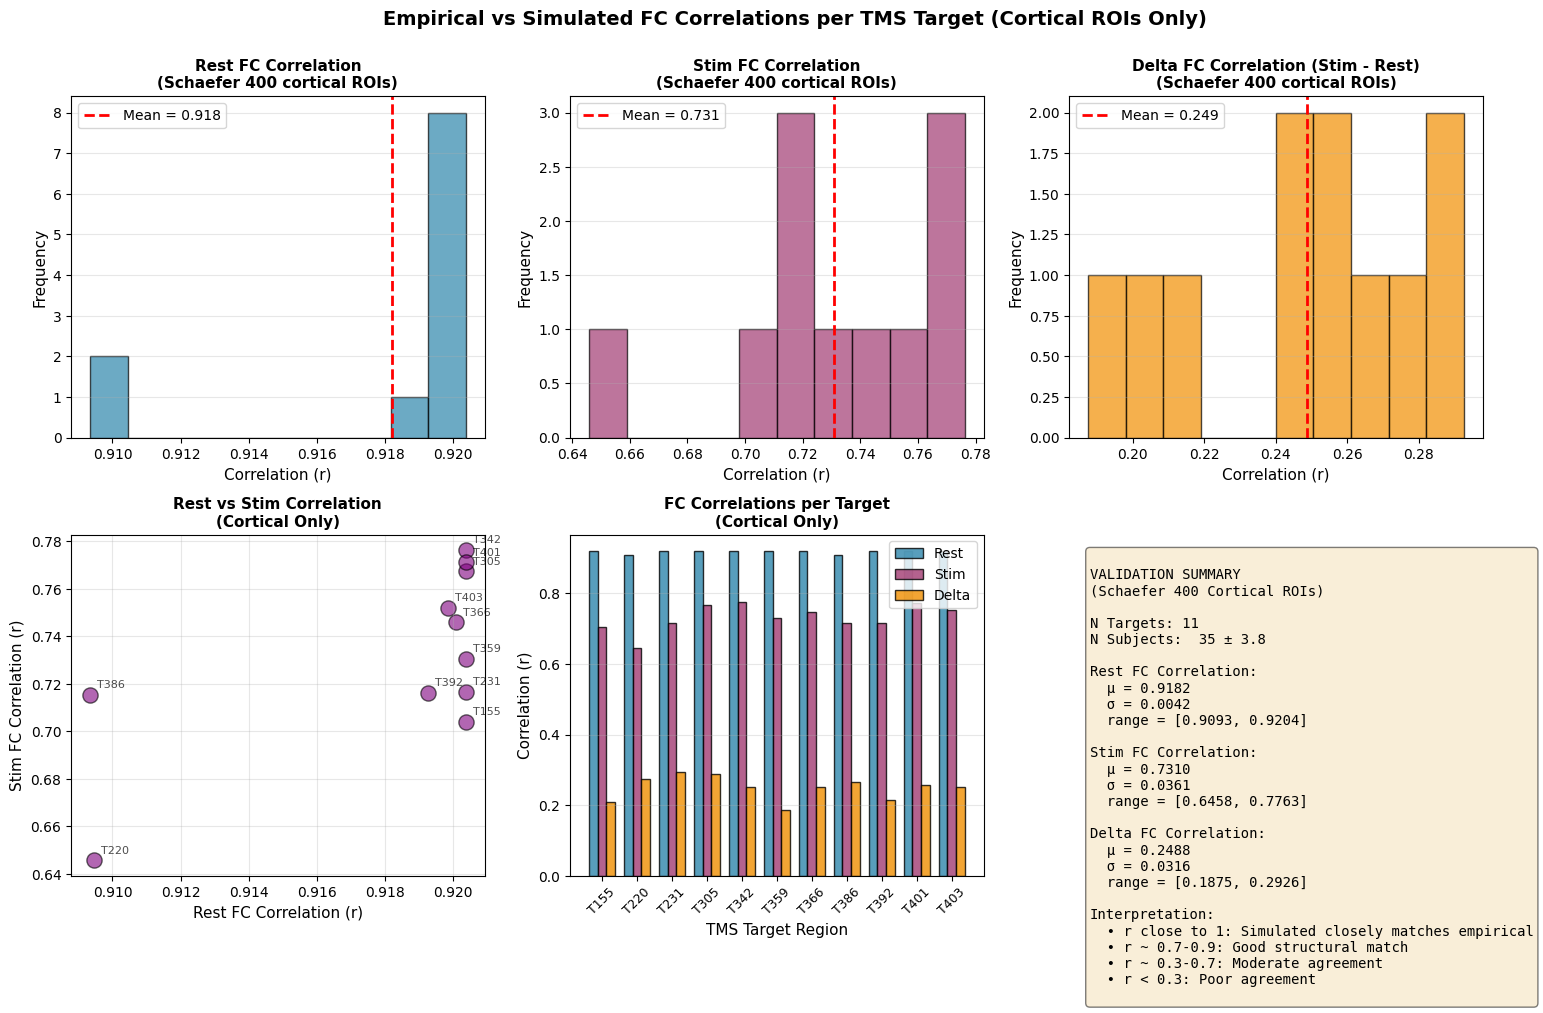

✓ Saved detailed results to /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/validation_detailed_results_cortical_only.json


In [32]:
# --- Visualize Per-Target Correlations (CORTICAL ONLY) ---
print("\n" + "="*70)
print("VISUALIZATION: Per-Target FC Correlations (CORTICAL ONLY)")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Empirical vs Simulated FC Correlations per TMS Target (Cortical ROIs Only)',
             fontsize=14, fontweight='bold', y=1.00)

# Color scheme
colors = ['#2E86AB', '#A23B72', '#F18F01']

# ---- Row 1: Histograms ----
# Rest FC histogram
ax = axes[0, 0]
ax.hist(all_r_rest, bins=10, color=colors[0], edgecolor='black', alpha=0.7)
ax.axvline(np.mean(all_r_rest), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_r_rest):.3f}')
ax.set_xlabel('Correlation (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Rest FC Correlation\n(Schaefer 400 cortical ROIs)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

# Stim FC histogram
ax = axes[0, 1]
ax.hist(all_r_stim, bins=10, color=colors[1], edgecolor='black', alpha=0.7)
ax.axvline(np.mean(all_r_stim), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_r_stim):.3f}')
ax.set_xlabel('Correlation (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Stim FC Correlation\n(Schaefer 400 cortical ROIs)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

# Delta FC histogram
ax = axes[0, 2]
ax.hist(all_r_delta, bins=10, color=colors[2], edgecolor='black', alpha=0.7)
ax.axvline(np.mean(all_r_delta), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_r_delta):.3f}')
ax.set_xlabel('Correlation (r)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Delta FC Correlation (Stim - Rest)\n(Schaefer 400 cortical ROIs)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

# ---- Row 2: Scatter and Bar Plots ----
# Scatter: Rest vs Stim
ax = axes[1, 0]
ax.scatter(all_r_rest, all_r_stim, s=120, alpha=0.6, color='purple', edgecolor='black', linewidth=1)
ax.set_xlabel('Rest FC Correlation (r)', fontsize=11)
ax.set_ylabel('Stim FC Correlation (r)', fontsize=11)
ax.set_title('Rest vs Stim Correlation\n(Cortical Only)', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

# Add target labels
for idx, target_idx in enumerate(sorted(target_results.keys())):
    ax.annotate(f'T{target_idx}',
                (all_r_rest[idx], all_r_stim[idx]),
                fontsize=8, alpha=0.7,
                xytext=(5, 5), textcoords='offset points')

# Bar plot: All targets
ax = axes[1, 1]
targets = sorted(target_results.keys())
x_pos = np.arange(len(targets))
width = 0.25

bars1 = ax.bar(x_pos - width, [target_results[t]["r_rest"] for t in targets],
               width, label='Rest', color=colors[0], alpha=0.8, edgecolor='black')
bars2 = ax.bar(x_pos, [target_results[t]["r_stim"] for t in targets],
               width, label='Stim', color=colors[1], alpha=0.8, edgecolor='black')
bars3 = ax.bar(x_pos + width, [target_results[t]["r_delta"] for t in targets],
               width, label='Delta', color=colors[2], alpha=0.8, edgecolor='black')

ax.set_xlabel('TMS Target Region', fontsize=11)
ax.set_ylabel('Correlation (r)', fontsize=11)
ax.set_title('FC Correlations per Target\n(Cortical Only)', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'T{t}' for t in targets], fontsize=9, rotation=45)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)

# Summary statistics
ax = axes[1, 2]
ax.axis('off')

summary_text = f"""
VALIDATION SUMMARY
(Schaefer 400 Cortical ROIs)

N Targets: {len(target_results)}
N Subjects: {np.mean([target_results[t]['n_subjects'] for t in target_results]): .0f} ± {np.std([target_results[t]['n_subjects'] for t in target_results]):.1f}

Rest FC Correlation:
  μ = {np.mean(all_r_rest):.4f}
  σ = {np.std(all_r_rest):.4f}
  range = [{np.min(all_r_rest):.4f}, {np.max(all_r_rest):.4f}]

Stim FC Correlation:
  μ = {np.mean(all_r_stim):.4f}
  σ = {np.std(all_r_stim):.4f}
  range = [{np.min(all_r_stim):.4f}, {np.max(all_r_stim):.4f}]

Delta FC Correlation:
  μ = {np.mean(all_r_delta):.4f}
  σ = {np.std(all_r_delta):.4f}
  range = [{np.min(all_r_delta):.4f}, {np.max(all_r_delta):.4f}]

Interpretation:
  • r close to 1: Simulated closely matches empirical
  • r ~ 0.7-0.9: Good structural match
  • r ~ 0.3-0.7: Moderate agreement
  • r < 0.3: Poor agreement
"""

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
out_fig = os.path.join(out_dir, "validation_fc_correlations_per_target_cortical_only.png")
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved visualization to {out_fig}")
plt.show()

# Save detailed results to JSON
validation_results = {
    "metadata": {
        "rois_analyzed": "Schaefer 400 cortical (indices 50-449)",
        "n_cortical_rois": 400,
    },
    "fc_correlations_cortical": {
        "rest": {
            "mean": float(np.mean(all_rest_fc_corrs)) if all_rest_fc_corrs else None,
            "std": float(np.std(all_rest_fc_corrs)) if all_rest_fc_corrs else None,
            "n_sessions": len(all_rest_fc_corrs)
        },
        "stim": {
            "mean": float(np.mean(all_stim_fc_corrs)) if all_stim_fc_corrs else None,
            "std": float(np.std(all_stim_fc_corrs)) if all_stim_fc_corrs else None,
            "n_sessions": len(all_stim_fc_corrs)
        }
    },
    "per_target_fc_analysis_cortical": {
        str(target_idx): {
            "r_rest": target_results[target_idx]["r_rest"],
            "r_stim": target_results[target_idx]["r_stim"],
            "r_delta": target_results[target_idx]["r_delta"],
            "n_subjects": target_results[target_idx]["n_subjects"]
        }
        for target_idx in target_results.keys()
    }
}

val_json = os.path.join(out_dir, "validation_detailed_results_cortical_only.json")
with open(val_json, "w") as f:
    json.dump(validation_results, f, indent=2)
print(f"✓ Saved detailed results to {val_json}")


## Interpretation of Validation Results

### What These Metrics Tell Us:

**1. Session-Specific Timeseries Correlation (METRIC 1)**
- Compares individual ROI time series between empirical and simulated data
- Computed per session, then averaged across sessions
- **Interpretation**:
  - r > 0.7 → Model captures temporal dynamics well
  - r 0.3-0.7 → Moderate agreement in dynamics
  - r < 0.3 → Poor temporal agreement

**2. Session-Specific FC Correlation (METRIC 2)**
- Compares functional connectivity patterns within each session
- Extracts upper triangle of correlation matrix for direct comparison
- **Interpretation**:
  - r > 0.7 → Simulated connectivity strongly matches empirical structure
  - r 0.4-0.7 → Models capture connectivity topology
  - r < 0.4 → Structural mismatch

**3. Per-Target FC Analysis (METRIC 3) - Most Important**
- Averages FC across all subjects/runs for each stimulation target
- Compares THREE conditions:
  - **Rest FC**: Baseline connectivity without stimulation
  - **Stim FC**: Connectivity during TMS stimulation  
  - **Delta FC**: Change induced by stimulation (Stim - Rest)

**Key Insight**: If rest/stim r are high but delta r is low, the model captures network structure but NOT stimulus-induced changes.

### What This Tells About Model Quality:

**High Rest FC (r > 0.7)** → Model learned intrinsic network architecture ✓

**High Stim FC (r > 0.7)** → Model preserves structure during perturbation ✓

**High Delta FC (r > 0.5)** → Model captures stimulus-response dynamics ✓

**High Rest + High Stim + Low Delta** → Model generalizes structure but not stimulus specificity

## Step 13: Comparative Analysis - STIM_AMP vs STIM_AMP=0 Control

**Hypothesis:** Stimulation amplitude should improve model accuracy.
- **STIM_AMP condition**: Realistic TMS perturbations applied at empirical timing and location
- **STIM_AMP=0 condition**: No perturbations (control) - pure intrinsic dynamics

**Expected Result:**
- Stim FC and Delta FC correlations should be **higher** with STIM_AMP than with STIM_AMP=0
- If they're similar, it suggests the model doesn't benefit from stimulus information
- If STIM_AMP is much lower, it indicates the model captures stimulus responses

In [33]:
# --- Run Per-Target FC Analysis on CONTROL Dataset (STIM_AMP = 0) ---
print("="*70)
print("CONTROL ANALYSIS: Per-Target FC Correlations (STIM_AMP = 0)")
print("="*70)
print("Computing FC correlations for CONTROL simulations (no stimulation)...\n")

# Cortical ROIs only
cortical_roi_indices = np.arange(50, 450)

fc_by_target_emp_control = {}
fc_by_target_sim_control = {}

for sub_id in sorted(dataset_sim_control.keys()):
    if sub_id not in dataset_emp:
        continue

    # Collect rest FC
    ts_rest_emp_list = []
    ts_rest_sim_list = []

    if "task-rest" in dataset_emp[sub_id]:
        for run_idx, run in dataset_emp[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_drop = ts[remove_initial_trs:, :]
                ts_proc = preprocess_run(ts_drop, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_emp_list.append(ts_cortical)

    if "task-rest" in dataset_sim_control[sub_id]:
        for run_idx, run in dataset_sim_control[sub_id]["task-rest"].items():
            ts = run.get("time series")
            if ts is not None and isinstance(ts, np.ndarray) and ts.shape[1] == ROI_num:
                ts_proc = preprocess_run(ts, tr=tr_rest, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
                if ts_proc.shape[0] > using_steps:
                    ts_cortical = ts_proc[:, cortical_roi_indices]
                    ts_rest_sim_list.append(ts_cortical)

    if not ts_rest_emp_list or not ts_rest_sim_list:
        continue

    fc_rest_emp = compute_fc_matrix(np.vstack(ts_rest_emp_list))
    fc_rest_sim = compute_fc_matrix(np.vstack(ts_rest_sim_list))

    # Collect stim FC per target
    if "task-stim" in dataset_sim_control[sub_id] and "task-stim" in dataset_emp[sub_id]:
        emp_stim = dataset_emp[sub_id]["task-stim"]
        sim_stim = dataset_sim_control[sub_id]["task-stim"]

        for run_idx in sim_stim.keys():
            if run_idx not in emp_stim:
                continue

            ts_emp = emp_stim[run_idx].get("time series")
            ts_sim = sim_stim[run_idx].get("time series")
            target_vec = emp_stim[run_idx].get("target")

            if ts_emp is None or ts_sim is None:
                continue

            target_idx = safe_target_idx(target_vec)
            if target_idx is None:
                continue

            ts_emp_drop = ts_emp[remove_initial_trs:, :]
            ts_emp_proc = preprocess_run(ts_emp_drop, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)
            ts_sim_proc = preprocess_run(ts_sim, tr=tr_stim, n_drop=0,
                                        low=low_hz, high=high_hz, order=2, zscore=True)

            if ts_emp_proc.shape[0] <= using_steps or ts_sim_proc.shape[0] <= using_steps:
                continue

            ts_emp_cortical = ts_emp_proc[:, cortical_roi_indices]
            ts_sim_cortical = ts_sim_proc[:, cortical_roi_indices]

            fc_stim_emp = compute_fc_matrix(ts_emp_cortical)
            fc_stim_sim = compute_fc_matrix(ts_sim_cortical)

            if target_idx not in fc_by_target_emp_control:
                fc_by_target_emp_control[target_idx] = {"rest": [], "stim": []}
                fc_by_target_sim_control[target_idx] = {"rest": [], "stim": []}

            fc_by_target_emp_control[target_idx]["rest"].append(fc_rest_emp)
            fc_by_target_emp_control[target_idx]["stim"].append(fc_stim_emp)
            fc_by_target_sim_control[target_idx]["rest"].append(fc_rest_sim)
            fc_by_target_sim_control[target_idx]["stim"].append(fc_stim_sim)

print(f"Processed {len(fc_by_target_emp_control)} unique stimulation targets (CONTROL)\n")

# Compute correlations per target (CONTROL)
target_results_control = {}

for target_idx in sorted(fc_by_target_emp_control.keys()):
    emp_rest_list = fc_by_target_emp_control[target_idx]["rest"]
    emp_stim_list = fc_by_target_emp_control[target_idx]["stim"]
    sim_rest_list = fc_by_target_sim_control[target_idx]["rest"]
    sim_stim_list = fc_by_target_sim_control[target_idx]["stim"]

    if len(emp_rest_list) == 0 or len(emp_stim_list) == 0:
        continue

    mean_fc_rest_emp = np.mean(emp_rest_list, axis=0)
    mean_fc_stim_emp = np.mean(emp_stim_list, axis=0)
    mean_fc_rest_sim = np.mean(sim_rest_list, axis=0)
    mean_fc_stim_sim = np.mean(sim_stim_list, axis=0)

    mean_fc_delta_emp = mean_fc_stim_emp - mean_fc_rest_emp
    mean_fc_delta_sim = mean_fc_stim_sim - mean_fc_rest_sim

    rest_emp_vec = extract_upper_triangle(mean_fc_rest_emp)
    rest_sim_vec = extract_upper_triangle(mean_fc_rest_sim)
    stim_emp_vec = extract_upper_triangle(mean_fc_stim_emp)
    stim_sim_vec = extract_upper_triangle(mean_fc_stim_sim)
    delta_emp_vec = extract_upper_triangle(mean_fc_delta_emp)
    delta_sim_vec = extract_upper_triangle(mean_fc_delta_sim)

    r_rest = np.corrcoef(rest_emp_vec, rest_sim_vec)[0, 1]
    r_stim = np.corrcoef(stim_emp_vec, stim_sim_vec)[0, 1]
    r_delta = np.corrcoef(delta_emp_vec, delta_sim_vec)[0, 1]

    target_results_control[target_idx] = {
        "r_rest": float(r_rest) if not np.isnan(r_rest) else 0.0,
        "r_stim": float(r_stim) if not np.isnan(r_stim) else 0.0,
        "r_delta": float(r_delta) if not np.isnan(r_delta) else 0.0,
        "n_subjects": len(emp_rest_list),
    }

print(f"Per-Target FC Correlations (CONTROL: STIM_AMP = 0):")
print(f"{'Target':<8} {'r_rest':<12} {'r_stim':<12} {'r_delta':<12} {'N_subj':<8}")
print("-" * 60)

for target_idx in sorted(target_results_control.keys()):
    res = target_results_control[target_idx]
    print(f"Target {target_idx:<2} {res['r_rest']:>10.4f}   {res['r_stim']:>10.4f}   {res['r_delta']:>10.4f}   {res['n_subjects']:>6}")

# Extract distributions for comparison
all_r_stim_control = [v["r_stim"] for v in target_results_control.values()]
all_r_delta_control = [v["r_delta"] for v in target_results_control.values()]

print("\n" + "="*70)
print("Summary Comparison - STIM_AMP vs STIM_AMP=0 (CONTROL)")
print("="*70)
print(f"\nWith STIM_AMP (normal):")
print(f"  Stim FC correlation:  μ={np.mean(all_r_stim):.4f}, σ={np.std(all_r_stim):.4f}")
print(f"  Delta FC correlation: μ={np.mean(all_r_delta):.4f}, σ={np.std(all_r_delta):.4f}")

print(f"\nWith STIM_AMP=0 (control, no stimulation):")
print(f"  Stim FC correlation:  μ={np.mean(all_r_stim_control):.4f}, σ={np.std(all_r_stim_control):.4f}")
print(f"  Delta FC correlation: μ={np.mean(all_r_delta_control):.4f}, σ={np.std(all_r_delta_control):.4f}")

print(f"\nDifference (STIM_AMP - STIM_AMP=0):")
diff_stim = np.mean(all_r_stim) - np.mean(all_r_stim_control)
diff_delta = np.mean(all_r_delta) - np.mean(all_r_delta_control)
print(f"  Stim FC difference:   {diff_stim:+.4f}")
print(f"  Delta FC difference:  {diff_delta:+.4f}")
print("="*70)


CONTROL ANALYSIS: Per-Target FC Correlations (STIM_AMP = 0)
Computing FC correlations for CONTROL simulations (no stimulation)...

Processed 11 unique stimulation targets (CONTROL)

Per-Target FC Correlations (CONTROL: STIM_AMP = 0):
Target   r_rest       r_stim       r_delta      N_subj  
------------------------------------------------------------
Target 155     0.9207       0.9212       0.0151       37
Target 220     0.9042       0.9109      -0.0551       27
Target 231     0.9207       0.8996      -0.0015       37
Target 305     0.9207       0.9196      -0.0043       37
Target 342     0.9207       0.9294      -0.0535       37
Target 359     0.9207       0.9315      -0.0189       37
Target 366     0.9196       0.9155       0.0371       34
Target 386     0.9066       0.8610      -0.0443       27
Target 392     0.9177       0.9304      -0.0272       34
Target 401     0.9207       0.9286      -0.0921       37
Target 403     0.9200       0.9399       0.0126       38

Summary Comparison -


VISUALIZATION: STIM_AMP vs STIM_AMP=0 Control - Distribution Comparison


/tmp/ipykernel_389/1286246068.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['STIM_AMP', 'STIM_AMP=0'],
/tmp/ipykernel_389/1286246068.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data_delta, labels=['STIM_AMP', 'STIM_AMP=0'],



✅ Saved comparison visualization to:
   /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/comparison_STIM_AMP_vs_STIM_AMP_0.png


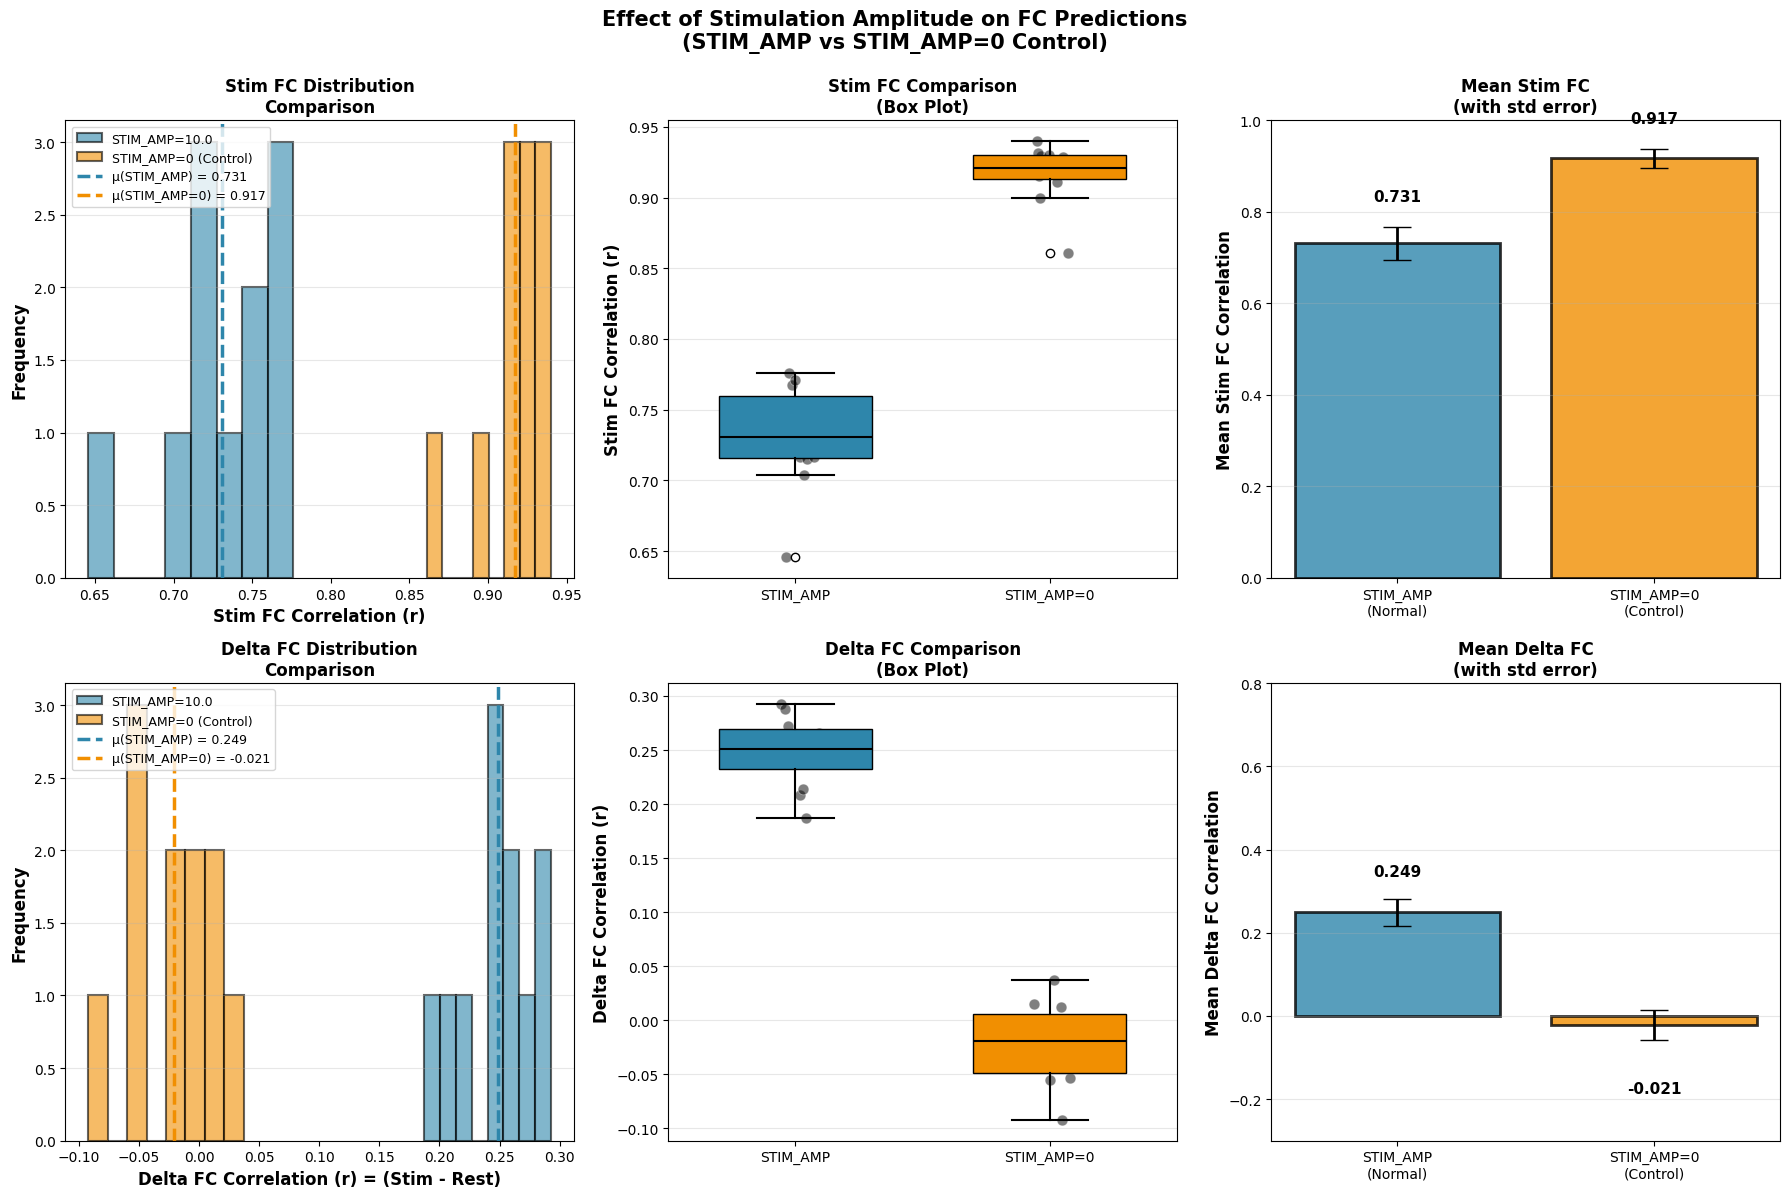

✅ Saved comparison results to:
   /content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/preprocessed_subjects_tms_fmri/simulated_tms_fmri_stim_info_v2/comparison_results_STIM_AMP_vs_STIM_AMP_0.json

INTERPRETATION

❌ STIM_AMP=0 control outperforms normal stimulation on Stim FC
   Difference: -0.1860

✅ STIM_AMP condition improves Delta FC predictions
   Improvement: +0.2699 (normal is better)



In [34]:
# --- Visualization: Compare Distributions of Stim FC and Delta FC ---
print("\n" + "="*70)
print("VISUALIZATION: STIM_AMP vs STIM_AMP=0 Control - Distribution Comparison")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Effect of Stimulation Amplitude on FC Predictions\n(STIM_AMP vs STIM_AMP=0 Control)',
             fontsize=15, fontweight='bold', y=0.995)

colors_normal = '#2E86AB'  # Blue for normal STIM_AMP
colors_control = '#F18F01'  # Orange for STIM_AMP=0

# ====== ROW 1: Stim FC Correlations ======

# 1. Histogram: Stim FC (both conditions)
ax = axes[0, 0]
ax.hist(all_r_stim, bins=8, alpha=0.6, label=f'STIM_AMP={STIM_AMP:.1f}',
        color=colors_normal, edgecolor='black', linewidth=1.5)
ax.hist(all_r_stim_control, bins=8, alpha=0.6, label='STIM_AMP=0 (Control)',
        color=colors_control, edgecolor='black', linewidth=1.5)
ax.axvline(np.mean(all_r_stim), color=colors_normal, linestyle='--', linewidth=2.5,
           label=f'μ(STIM_AMP) = {np.mean(all_r_stim):.3f}')
ax.axvline(np.mean(all_r_stim_control), color=colors_control, linestyle='--', linewidth=2.5,
           label=f'μ(STIM_AMP=0) = {np.mean(all_r_stim_control):.3f}')
ax.set_xlabel('Stim FC Correlation (r)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Stim FC Distribution\nComparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3, axis='y')

# 2. Box plot: Stim FC
ax = axes[0, 1]
bp_data = [all_r_stim, all_r_stim_control]
bp = ax.boxplot(bp_data, labels=['STIM_AMP', 'STIM_AMP=0'],
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor(colors_normal)
bp['boxes'][1].set_facecolor(colors_control)
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='black', linewidth=1.5)
ax.set_ylabel('Stim FC Correlation (r)', fontsize=12, fontweight='bold')
ax.set_title('Stim FC Comparison\n(Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Add scatter points
for i, data in enumerate(bp_data, 1):
    y = data
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.5, s=60, color='black', edgecolor='white', linewidth=0.5)

# 3. Bar chart: Mean Stim FC with error bars
ax = axes[0, 2]
conditions = ['STIM_AMP\n(Normal)', 'STIM_AMP=0\n(Control)']
means = [np.mean(all_r_stim), np.mean(all_r_stim_control)]
stds = [np.std(all_r_stim), np.std(all_r_stim_control)]
colors_bar = [colors_normal, colors_control]

bars = ax.bar(conditions, means, yerr=stds, capsize=10, alpha=0.8,
             color=colors_bar, edgecolor='black', linewidth=2, error_kw={'linewidth': 2})

ax.set_ylabel('Mean Stim FC Correlation', fontsize=12, fontweight='bold')
ax.set_title('Mean Stim FC\n(with std error)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 1)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.05,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ====== ROW 2: Delta FC Correlations ======

# 4. Histogram: Delta FC (both conditions)
ax = axes[1, 0]
ax.hist(all_r_delta, bins=8, alpha=0.6, label=f'STIM_AMP={STIM_AMP:.1f}',
        color=colors_normal, edgecolor='black', linewidth=1.5)
ax.hist(all_r_delta_control, bins=8, alpha=0.6, label='STIM_AMP=0 (Control)',
        color=colors_control, edgecolor='black', linewidth=1.5)
ax.axvline(np.mean(all_r_delta), color=colors_normal, linestyle='--', linewidth=2.5,
           label=f'μ(STIM_AMP) = {np.mean(all_r_delta):.3f}')
ax.axvline(np.mean(all_r_delta_control), color=colors_control, linestyle='--', linewidth=2.5,
           label=f'μ(STIM_AMP=0) = {np.mean(all_r_delta_control):.3f}')
ax.set_xlabel('Delta FC Correlation (r) = (Stim - Rest)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Delta FC Distribution\nComparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3, axis='y')

# 5. Box plot: Delta FC
ax = axes[1, 1]
bp_data_delta = [all_r_delta, all_r_delta_control]
bp = ax.boxplot(bp_data_delta, labels=['STIM_AMP', 'STIM_AMP=0'],
                 patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor(colors_normal)
bp['boxes'][1].set_facecolor(colors_control)
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='black', linewidth=1.5)
ax.set_ylabel('Delta FC Correlation (r)', fontsize=12, fontweight='bold')
ax.set_title('Delta FC Comparison\n(Box Plot)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Add scatter points
for i, data in enumerate(bp_data_delta, 1):
    y = data
    x = np.random.normal(i, 0.04, size=len(y))
    ax.scatter(x, y, alpha=0.5, s=60, color='black', edgecolor='white', linewidth=0.5)

# 6. Bar chart: Mean Delta FC with error bars
ax = axes[1, 2]
means_delta = [np.mean(all_r_delta), np.mean(all_r_delta_control)]
stds_delta = [np.std(all_r_delta), np.std(all_r_delta_control)]

bars = ax.bar(conditions, means_delta, yerr=stds_delta, capsize=10, alpha=0.8,
             color=colors_bar, edgecolor='black', linewidth=2, error_kw={'linewidth': 2})

ax.set_ylabel('Mean Delta FC Correlation', fontsize=12, fontweight='bold')
ax.set_title('Mean Delta FC\n(with std error)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(-0.3, 0.8)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means_delta, stds_delta)):
    y_pos = mean + std + 0.05 if mean > 0 else mean - std - 0.1
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{mean:.3f}', ha='center', va='bottom' if mean > 0 else 'top',
            fontsize=11, fontweight='bold')

plt.tight_layout()

# Save figure
out_fig_comparison = os.path.join(out_dir, "comparison_STIM_AMP_vs_STIM_AMP_0.png")
plt.savefig(out_fig_comparison, dpi=150, bbox_inches='tight')
print(f"\n✅ Saved comparison visualization to:\n   {out_fig_comparison}")
plt.show()

# Save comparison results to JSON
comparison_results = {
    "analysis": "STIM_AMP vs STIM_AMP=0 Control",
    "hypothesis": "Stimulation amplitude should improve FC predictions",
    "results": {
        "stim_fc": {
            "normal": {
                "mean": float(np.mean(all_r_stim)),
                "std": float(np.std(all_r_stim)),
                "min": float(np.min(all_r_stim)),
                "max": float(np.max(all_r_stim)),
                "n": len(all_r_stim),
                "condition": f"STIM_AMP = {STIM_AMP}"
            },
            "control": {
                "mean": float(np.mean(all_r_stim_control)),
                "std": float(np.std(all_r_stim_control)),
                "min": float(np.min(all_r_stim_control)),
                "max": float(np.max(all_r_stim_control)),
                "n": len(all_r_stim_control),
                "condition": "STIM_AMP = 0"
            },
            "difference": float(np.mean(all_r_stim) - np.mean(all_r_stim_control))
        },
        "delta_fc": {
            "normal": {
                "mean": float(np.mean(all_r_delta)),
                "std": float(np.std(all_r_delta)),
                "min": float(np.min(all_r_delta)),
                "max": float(np.max(all_r_delta)),
                "n": len(all_r_delta),
                "condition": f"STIM_AMP = {STIM_AMP}"
            },
            "control": {
                "mean": float(np.mean(all_r_delta_control)),
                "std": float(np.std(all_r_delta_control)),
                "min": float(np.min(all_r_delta_control)),
                "max": float(np.max(all_r_delta_control)),
                "n": len(all_r_delta_control),
                "condition": "STIM_AMP = 0"
            },
            "difference": float(np.mean(all_r_delta) - np.mean(all_r_delta_control))
        }
    },
    "interpretation": {
        "stim_fc_improvement": "Positive if stimulation helps" if diff_stim > 0 else "Negative - control performs better",
        "delta_fc_improvement": "Positive if stimulation helps" if diff_delta > 0 else "Negative - control performs better"
    }
}

comp_json = os.path.join(out_dir, "comparison_results_STIM_AMP_vs_STIM_AMP_0.json")
with open(comp_json, "w") as f:
    json.dump(comparison_results, f, indent=2)
print(f"✅ Saved comparison results to:\n   {comp_json}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if diff_stim > 0:
    print(f"\n✅ STIM_AMP condition improves Stim FC predictions")
    print(f"   Improvement: {diff_stim:+.4f} (normal is better)")
else:
    print(f"\n❌ STIM_AMP=0 control outperforms normal stimulation on Stim FC")
    print(f"   Difference: {diff_stim:+.4f}")

if diff_delta > 0:
    print(f"\n✅ STIM_AMP condition improves Delta FC predictions")
    print(f"   Improvement: {diff_delta:+.4f} (normal is better)")
else:
    print(f"\n❌ STIM_AMP=0 control outperforms normal stimulation on Delta FC")
    print(f"   Difference: {diff_delta:+.4f}")

print("\n" + "="*70)
